Patch not applied (pattern not found). Continuing anyway.
Using checkpoint: Epoch_56
Running: /Users/shuber/Development/PenPlotter/.venv/bin/python /Users/shuber/Development/PenPlotter/patterns/pytorch-handwriting-synthesis-toolkit/synthesize.py /Users/shuber/Development/PenPlotter/patterns/pytorch-handwriting-synthesis-toolkit/checkpoints/Epoch_56 Handwriting synthesis demo --samples_dir /var/folders/h9/sfs97_5d7dj5j9jvqsbxh5wr0000gn/T/synth_svg_lines_hb54abdt/line_001 --output_file_type svg --trials 1 --thickness 10 -b 0
Namespace(model_path='/Users/shuber/Development/PenPlotter/patterns/pytorch-handwriting-synthesis-toolkit/checkpoints/Epoch_56', text='Handwriting synthesis demo', bias=0.0, trials=1, show_weights=False, heatmap=False, samples_dir='/var/folders/h9/sfs97_5d7dj5j9jvqsbxh5wr0000gn/T/synth_svg_lines_hb54abdt/line_001', thickness=10, output_file_type='svg')
Done 1 / 1
Running: /Users/shuber/Development/PenPlotter/.venv/bin/python /Users/shuber/Development/PenPlotter/patte

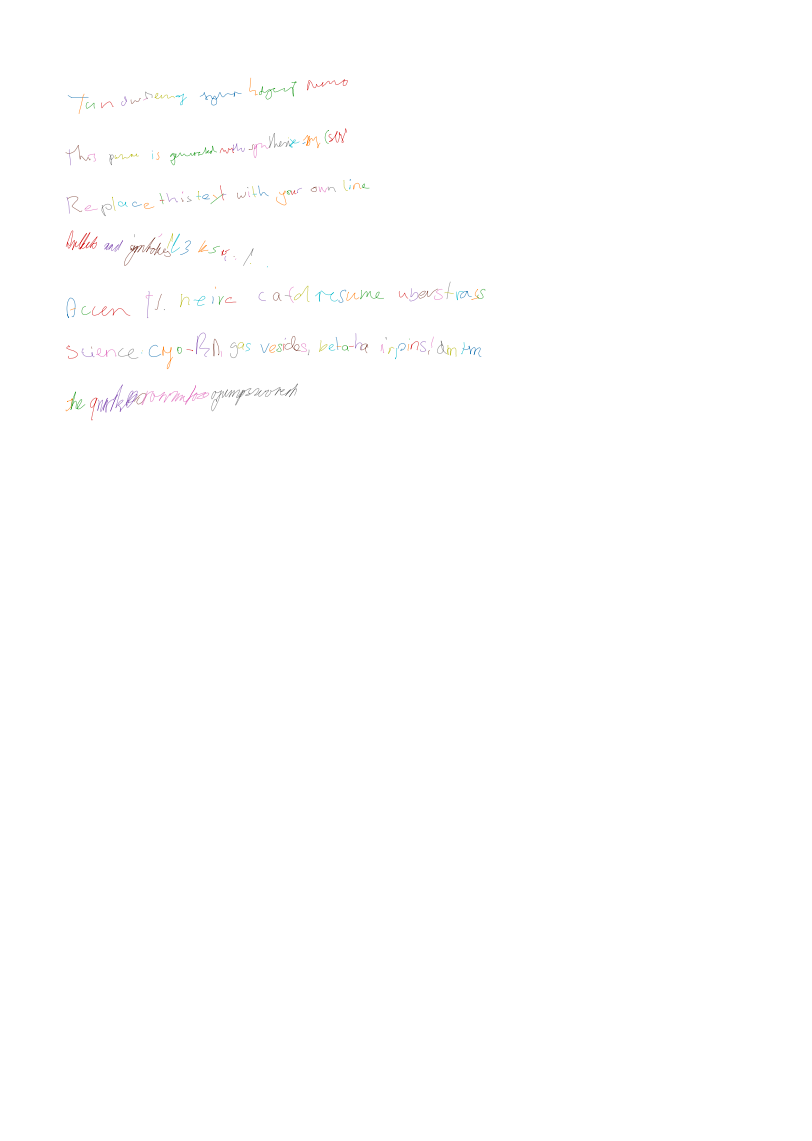

Saved: /Users/shuber/Development/PenPlotter/patterns/06_handwriting_page_from_synthesize.svg


In [41]:
# Fix warning + remove black rectangle, then lay out an A4 SVG page
# - runs from patterns/
# - uses ../.venv/bin/python
# - patches handwriting_synthesis/models.py to use torch.stack for sigma
# - generates per-line SVGs with synthesize.py (SVG)
# - removes border rectangle during composition
# - saves handwriting_page_from_synthesize.svg

import sys, re, subprocess, tempfile
from pathlib import Path
import textwrap
import numpy as np
import matplotlib.pyplot as plt

# ---------- paths ----------
BASE_DIR = Path.cwd()                               # patterns/
VENV_PY   = BASE_DIR.parent / ".venv" / "bin" / "python"
REPO_DIR  = BASE_DIR / "pytorch-handwriting-synthesis-toolkit"
SYNTH     = REPO_DIR / "synthesize.py"
MODELS_PY = REPO_DIR / "handwriting_synthesis" / "models.py"
OUT_SVG   = BASE_DIR / "06_handwriting_page_from_synthesize.svg"

# ---------- patch models.py to avoid the torch scalar warning ----------
def patch_sigma(models_py: Path) -> bool:
    txt = models_py.read_text(encoding="utf-8")
    # Replace any 'sigma = torch.tensor([[sd1 ** 2, cov_x_y], [cov_x_y, sd2 ** 2]])'
    # with a grad-safe stack construction that keeps dtype/device and avoids scalar conversion
    pat = r"""sigma\s*=\s*torch\.tensor\(\s*\[\s*\[\s*sd1\s*\*\*\s*2\s*,\s*cov_x_y\s*\]\s*,\s*\[\s*cov_x_y\s*,\s*sd2\s*\*\*\s*2\s*\]\s*\]\s*\)"""
    repl = "sigma = torch.stack([torch.stack([sd1 ** 2, cov_x_y]), torch.stack([cov_x_y, sd2 ** 2])])"
    new_txt, n = re.subn(pat, repl, txt)
    if n == 0:
        # fallback: patch any 'torch.tensor([[..., ...], [..., ...]])' that assigns to sigma
        pat2 = r"""sigma\s*=\s*torch\.tensor\(\s*\[\s*\[\s*([^\]]+)\]\s*,\s*\[\s*([^\]]+)\]\s*\]\s*\)"""
        repl2 = r"sigma = torch.stack([torch.stack([\1]), torch.stack([\2])])"
        new_txt, n = re.subn(pat2, repl2, txt)
    if n > 0:
        models_py.write_text(new_txt, encoding="utf-8")
        print(f"Patched sigma in {models_py} ({n} change).")
        return True
    else:
        print("Patch not applied (pattern not found). Continuing anyway.")
        return False

if not MODELS_PY.exists():
    raise FileNotFoundError(f"Cannot find {MODELS_PY}")

patch_sigma(MODELS_PY)

# ---------- deps for SVG parsing in THIS kernel ----------
def ensure(pkg):
    try:
        __import__(pkg)
    except Exception:
        print(f"Installing {pkg} into the current kernel...")
        subprocess.run([sys.executable, "-m", "pip", "install", pkg], check=True)

ensure("svgpathtools")
from svgpathtools import svg2paths2

# ---------- generate per-line SVGs with synthesize.py ----------
# checkpoint
ckpt_dir = REPO_DIR / "checkpoints"
ckpts = sorted(ckpt_dir.glob("Epoch_*"))
if not ckpts:
    raise FileNotFoundError(f"No checkpoints in {ckpt_dir}")
CKPT = ckpts[-1]
print(f"Using checkpoint: {CKPT.name}")

# text lines
sample_text = textwrap.dedent("""
    Handwriting synthesis demo
    This page is generated with synthesize.py (SVG)
    Replace this text with your own lines
    Bullets and symbols: 1 2 3 4 5 , . ; : ! ?
    Accents: naive cafe resume uberstrasse
    Science: cryo-EM, gas vesicles, beta hairpins, dG, um
    The quick brown fox jumps over the lazy dog
""").strip("\n")
LINES = [ln.strip() for ln in sample_text.splitlines() if ln.strip()]

tmp_root = Path(tempfile.mkdtemp(prefix="synth_svg_lines_"))
line_svgs = []
for i, text in enumerate(LINES, 1):
    line_dir = tmp_root / f"line_{i:03d}"
    line_dir.mkdir(parents=True, exist_ok=True)
    cmd = [
        str(VENV_PY),
        str(SYNTH),
        str(CKPT),
        text,
        "--samples_dir", str(line_dir),
        "--output_file_type", "svg",
        "--trials", "1",
        "--thickness", "10",
        "-b", "0",
    ]
    print("Running:", " ".join(cmd))
    # In case the repo imports ever trigger warnings, this keeps output clean. Remove if you want to see them.
    env = dict(**os.environ) if "os" in globals() else __import__("os").environ.copy()
    env["PYTHONWARNINGS"] = env.get("PYTHONWARNINGS", "")  # do not suppress globally
    subprocess.run(cmd, cwd=str(REPO_DIR), check=True, env=env)
    produced = sorted(line_dir.glob("*.svg"))
    if not produced:
        raise FileNotFoundError(f"No SVG produced for line {i} in {line_dir}")
    line_svgs.append(produced[0])

print(f"Generated {len(line_svgs)} line SVGs")

# ---------- helpers to draw SVGs as vector lines and skip borders ----------
def svg_viewbox(svg_attr):
    if "viewBox" in svg_attr:
        vb = list(map(float, svg_attr["viewBox"].replace(",", " ").split()))
        sxmin, symin, sw, sh = vb
        return sxmin, symin, sw, sh
    # fallback if no viewBox
    w = float("".join(ch for ch in svg_attr.get("width", "0") if ch.isdigit() or ch in ".-+eE")) or 1.0
    h = float("".join(ch for ch in svg_attr.get("height", "0") if ch.isdigit() or ch in ".-+eE")) or 1.0
    return 0.0, 0.0, w, h

def path_sample_bbox(path, samples=40):
    xs, ys = [], []
    for seg in path:
        ts = np.linspace(0, 1, samples, endpoint=True)
        pts = [seg.point(t) for t in ts]
        xs.extend([z.real for z in pts])
        ys.extend([z.imag for z in pts])
    if not xs:
        return 0,0,0,0
    return min(xs), min(ys), max(xs), max(ys)

def is_border_like(path, sxmin, symin, sw, sh, tol=0.01):
    # border if bbox ~ full viewBox and segments are mostly straight
    pxmin, pymin, pxmax, pymax = path_sample_bbox(path, samples=4)
    w_ok = abs((pxmax - pxmin) - sw) <= tol * sw
    h_ok = abs((pymax - pymin) - sh) <= tol * sh
    x_ok = abs(pxmin - sxmin) <= tol * sw
    y_ok = abs(pymin - symin) <= tol * sh
    return w_ok and h_ok and x_ok and y_ok

def draw_svg_line(ax, svg_path, target_x, baseline_y, target_height_mm, max_width_mm):
    paths, attrs, svg_attr = svg2paths2(str(svg_path))
    sxmin, symin, sw, sh = svg_viewbox(svg_attr)
    if sw <= 0 or sh <= 0:
        return 0.0
    # scale by height, cap by width
    s_h = target_height_mm / sh
    s_w_cap = max_width_mm / sw
    s = min(s_h, s_w_cap)
    # left align and center vertically around baseline
    x_left = target_x
    y_center = baseline_y
    # flip y to mm-up
    flipY = True

    for p, a in zip(paths, attrs):
        if is_border_like(p, sxmin, symin, sw, sh):
            continue  # drop the rectangle border

        xs, ys = [], []
        ts = np.linspace(0, 1, 40, endpoint=True)
        for seg in p:
            pts = [seg.point(t) for t in ts]
            xs.extend([x_left + s * (z.real - sxmin) for z in pts])
            y_raw = [s * (z.imag - symin) for z in pts]
            if flipY:
                y_raw = [sh * s - y for y in y_raw]
            ys.extend([y_center + (yy - (sh * s) / 2.0) for yy in y_raw])

        ax.plot(xs, ys, linewidth=0.35)  # vector strokes

    return sh * s

# ---------- compose on A4 ----------
A4_W_MM, A4_H_MM = 210.0, 297.0
MARGIN_L = 14.0
MARGIN_R = 14.0
MARGIN_T = 18.0
MARGIN_B = 18.0

CONTENT_W = A4_W_MM - MARGIN_L - MARGIN_R

TARGET_LINE_H = 10.0
LINE_SPACING  = 1.35  # multiples of TARGET_LINE_H

fig = plt.figure(figsize=(A4_W_MM / 25.4, A4_H_MM / 25.4), dpi=96)
ax = plt.axes([0, 0, 1, 1])
ax.set_xlim(0, A4_W_MM)
ax.set_ylim(0, A4_H_MM)
ax.axis("off")

y = A4_H_MM - MARGIN_T - TARGET_LINE_H / 2.0
for i, svg in enumerate(line_svgs, 1):
    if y - TARGET_LINE_H / 2.0 < MARGIN_B:
        print("Out of space on A4. Stopping.")
        break
    _ = draw_svg_line(ax, svg, target_x=MARGIN_L, baseline_y=y,
                      target_height_mm=TARGET_LINE_H, max_width_mm=CONTENT_W)
    y -= LINE_SPACING * TARGET_LINE_H

plt.savefig(OUT_SVG, format="svg", bbox_inches="tight", pad_inches=0)
plt.show()
print(f"Saved: {OUT_SVG.resolve()}")


In [44]:
# # Archimedean spiral text layout (vector) using synthesize.py SVG outputs
# # Run from: patterns/
# # Uses:     ../.venv/bin/python
# # Repo:     patterns/pytorch-handwriting-synthesis-toolkit

# import sys, subprocess, tempfile, math, random
# from pathlib import Path

# import numpy as np
# import matplotlib.pyplot as plt

# # ------------- paths -------------
# BASE_DIR = Path.cwd()                               # patterns/
# VENV_PY   = BASE_DIR.parent / ".venv" / "bin" / "python"
# REPO_DIR  = BASE_DIR / "pytorch-handwriting-synthesis-toolkit"
# SYNTH     = REPO_DIR / "synthesize.py"
# OUT_SVG   = BASE_DIR / "handwriting_spiral.svg"

# # ------------- ensure svgpathtools in THIS kernel -------------
# def ensure(pkg):
#     try:
#         __import__(pkg)
#     except Exception:
#         print(f"Installing {pkg}...")
#         subprocess.run([sys.executable, "-m", "pip", "install", pkg], check=True)

# ensure("svgpathtools")
# from svgpathtools import svg2paths2

# # ------------- A4 and spiral params -------------
# A4_W_MM, A4_H_MM = 210.0, 297.0
# MARGIN_L = 40.0
# MARGIN_R = 40.0
# MARGIN_T = 40.0
# MARGIN_B = 40.0

# CX = A4_W_MM / 2.0
# CY = A4_H_MM / 2.0

# # Archimedean spiral r = a + b * theta (theta in radians, r in mm)
# A_SPIRAL = 0.0                   # mm
# B_SPIRAL = 10.0                   # mm per rad (turn spacing ~ 2*pi*B)
# THETA_START = 0.0                # start in center
# THETA_MAX   = 30.0               # big enough; we stop earlier if we hit page edge

# # Text styling
# TARGET_CHUNK_HEIGHT = 30.0        # mm visual height for each chunk
# CHUNK_GAP_MM = 2.0               # extra gap along the spiral between chunks
# BIAS = "0.0"                     # synthesize.py bias for neatness vs variety
# THICKNESS = "10"                 # stroke thickness hint for generator

# # ------------- lorem ipsum source -------------
# lipsum = (
#     "Lorem ipsum dolor sit amet, consectetur adipiscing elit, "
#     "sed do eiusmod tempor incididunt ut labore et dolore magna aliqua. "
#     "Ut enim ad minim veniam, quis nostrud exercitation ullamco laboris "
#     "nisi ut aliquip ex ea commodo consequat. Duis aute irure dolor in "
#     "reprehenderit in voluptate velit esse cillum dolore eu fugiat nulla pariatur. "
#     "Excepteur sint occaecat cupidatat non proident, sunt in culpa qui officia "
#     "deserunt mollit anim id est laborum."
# )

# WORDS = lipsum.split()
# # Repeat if needed
# WORDS = (WORDS * 50)  # plenty

# # Make small word chunks for nicer curvature following
# random.seed(7)
# chunks = []
# i = 0
# while i < len(WORDS):
#     n = random.randint(3, 6)  # 3 to 6 words per chunk
#     chunk = " ".join(WORDS[i:i+n])
#     if not chunk:
#         break
#     chunks.append(chunk)
#     i += n

# # ------------- helpers -------------
# def pick_checkpoint():
#     ckpt_dir = REPO_DIR / "checkpoints"
#     ckpts = sorted(ckpt_dir.glob("Epoch_*"))
#     if not ckpts:
#         raise FileNotFoundError(f"No checkpoints found in {ckpt_dir}")
#     return ckpts[-1]

# def svg_viewbox(svg_attr):
#     if "viewBox" in svg_attr:
#         vb = list(map(float, svg_attr["viewBox"].replace(",", " ").split()))
#         return vb  # [xmin, ymin, w, h]
#     # fallback to width/height if missing
#     def _num(v):
#         if v is None: return None
#         s = "".join(ch for ch in v if (ch.isdigit() or ch in ".-+eE"))
#         try: return float(s)
#         except: return None
#     w = _num(svg_attr.get("width")) or 1.0
#     h = _num(svg_attr.get("height")) or 1.0
#     return [0.0, 0.0, w, h]

# def draw_svg_at(ax, svg_path, center_x, center_y, angle_rad, target_height_mm, max_width_mm):
#     """
#     Place one SVG chunk with its left-middle anchored at (center_x, center_y),
#     rotated by angle_rad (radians), scaled to target_height_mm, capped by max_width_mm.
#     Returns the drawn width in mm.
#     """
#     paths, attrs, svg_attr = svg2paths2(str(svg_path))
#     sxmin, symin, sw, sh = svg_viewbox(svg_attr)
#     if sw <= 0 or sh <= 0:
#         return 0.0

#     # Scale to height, cap by width
#     s_h = target_height_mm / sh
#     s_w_cap = max_width_mm / sw
#     s = min(s_h, s_w_cap)

#     # Build rotation
#     ca, sa = math.cos(angle_rad), math.sin(angle_rad)

#     # Sample and draw
#     SAMPLES = 40
#     for p, a in zip(paths, attrs):
#         # Drop border rectangle if present
#         # Fast bbox test by sampling segment ends
#         xsB = [seg.start.real for seg in p] + [seg.end.real for seg in p]
#         ysB = [seg.start.imag for seg in p] + [seg.end.imag for seg in p]
#         if xsB and ysB:
#             pxmin, pxmax = min(xsB), max(xsB)
#             pymin, pymax = min(ysB), max(ysB)
#             if (abs((pxmax - pxmin) - sw) <= 0.01*sw and
#                 abs((pymax - pymin) - sh) <= 0.01*sh and
#                 abs(pxmin - sxmin) <= 0.01*sw and
#                 abs(pymin - symin) <= 0.01*sh):
#                 continue  # looks like a full-frame border

#         xs, ys = [], []
#         for seg in p:
#             ts = np.linspace(0, 1, SAMPLES, endpoint=True)
#             pts = [seg.point(t) for t in ts]
#             # Left-middle anchor: subtract left (sxmin) and center vertically (sh/2)
#             x0 = [(z.real - sxmin) * s for z in pts]
#             y0 = [(z.imag - symin) * s for z in pts]
#             # Flip Y to mm-up and center vertically
#             y0 = [(sh * s) - y for y in y0]
#             y0 = [y - (sh * s) / 2.0 for y in y0]
#             # Rotate
#             xr = [ca * x - sa * y for x, y in zip(x0, y0)]
#             yr = [sa * x + ca * y for x, y in zip(x0, y0)]
#             # Translate
#             xs.extend([center_x + x for x in xr])
#             ys.extend([center_y + y for y in yr])

#         ax.plot(xs, ys, linewidth=0.35)

#     return sw * s  # width consumed along the tangent

# def spiral_xy(theta):
#     r = A_SPIRAL + B_SPIRAL * theta
#     x = CX + r * math.cos(theta)
#     y = CY + r * math.sin(theta)
#     return x, y, r

# def spiral_tangent_angle(theta):
#     # Parametric derivative for r = a + b theta
#     r = A_SPIRAL + B_SPIRAL * theta
#     b = B_SPIRAL
#     dx = b * math.cos(theta) - r * math.sin(theta)
#     dy = b * math.sin(theta) + r * math.cos(theta)
#     return math.atan2(dy, dx)

# def dtheta_for_arc(theta, s_mm):
#     # local arc metric: ds = sqrt(r^2 + b^2) dtheta
#     r = A_SPIRAL + B_SPIRAL * theta
#     return s_mm / math.sqrt(r*r + B_SPIRAL*B_SPIRAL)

# # ------------- generate chunk SVGs -------------
# CKPT = pick_checkpoint()
# tmp_root = Path(tempfile.mkdtemp(prefix="spiral_chunks_"))
# chunk_svgs = []

# for i, text in enumerate(chunks, 1):
#     out_dir = tmp_root / f"chunk_{i:04d}"
#     out_dir.mkdir(parents=True, exist_ok=True)
#     cmd = [
#         str(VENV_PY),
#         str(SYNTH),
#         str(CKPT),
#         text,
#         "--samples_dir", str(out_dir),
#         "--output_file_type", "svg",
#         "--trials", "1",
#         "--thickness", THICKNESS,
#         "-b", BIAS,
#     ]
#     subprocess.run(cmd, cwd=str(REPO_DIR), check=True)
#     svgs = sorted(out_dir.glob("*.svg"))
#     if not svgs:
#         continue
#     chunk_svgs.append((text, svgs[0]))

# print(f"Prepared {len(chunk_svgs)} SVG chunks.")

# # ------------- compose on A4 -------------
# fig = plt.figure(figsize=(A4_W_MM / 25.4, A4_H_MM / 25.4), dpi=96)
# ax = plt.axes([0, 0, 1, 1])
# ax.set_xlim(0, A4_W_MM)
# ax.set_ylim(0, A4_H_MM)
# ax.axis("off")

# # Optional: margin guide
# # ax.plot([MARGIN_L, A4_W_MM - MARGIN_R, A4_W_MM - MARGIN_R, MARGIN_L, MARGIN_L],
# #         [MARGIN_B, MARGIN_B, A4_H_MM - MARGIN_T, A4_H_MM - MARGIN_T, MARGIN_B],
# #         linewidth=0.2)

# theta = THETA_START
# max_w = A4_W_MM - MARGIN_L - MARGIN_R
# keep_inside = lambda x,y: (MARGIN_L <= x <= A4_W_MM - MARGIN_R) and (MARGIN_B <= y <= A4_H_MM - MARGIN_T)

# for text, svg in chunk_svgs:
#     x, y, r = spiral_xy(theta)
#     if not keep_inside(x, y):
#         break

#     angle = spiral_tangent_angle(theta)

#     used_width = draw_svg_at(
#         ax, svg_path=svg,
#         center_x=x, center_y=y,
#         angle_rad=angle,
#         target_height_mm=TARGET_CHUNK_HEIGHT,
#         max_width_mm=max_w
#     )

#     # advance theta by local arc length equal to used width plus gap
#     step_mm = used_width + CHUNK_GAP_MM
#     theta += dtheta_for_arc(theta, step_mm)

#     if theta > THETA_MAX:
#         break

# plt.savefig(OUT_SVG, format="svg", bbox_inches="tight", pad_inches=0)
# plt.show()
# print(f"Saved spiral page: {OUT_SVG.resolve()}")

# # If you want to keep the temp SVGs, comment this out.
# # import shutil; shutil.rmtree(tmp_root)


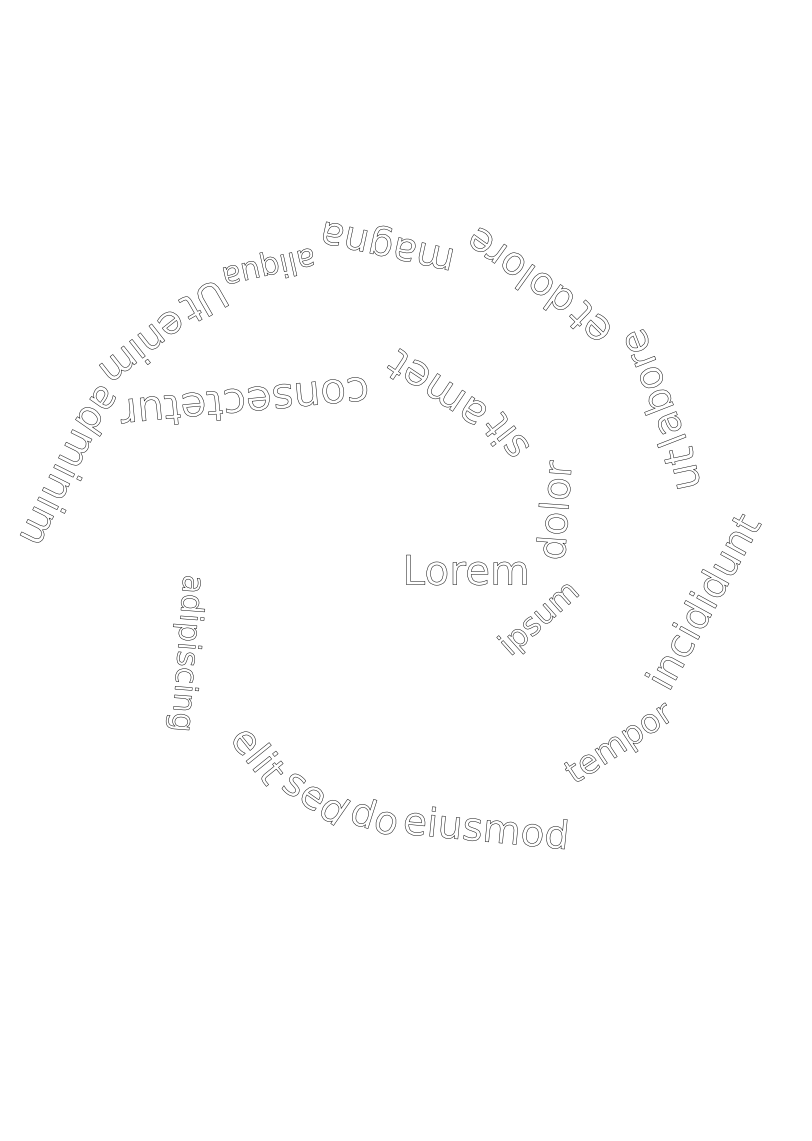

Saved vector SVG: /Users/shuber/Development/PenPlotter/patterns/06_spiral_text.svg


In [45]:
# Spiral text (pure vector glyph outlines) on A4, saved as SVG
# Run from anywhere; no external deps beyond matplotlib

import math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.textpath import TextPath
from matplotlib.patches import PathPatch
from matplotlib.font_manager import FontProperties
from matplotlib.transforms import Affine2D

# ---------------- A4 layout ----------------
A4_W_MM, A4_H_MM = 210.0, 297.0
MARGIN_L, MARGIN_R, MARGIN_T, MARGIN_B = 14.0, 14.0, 18.0, 18.0
CX, CY = A4_W_MM / 2.0, A4_H_MM / 2.0
SVG_OUT = Path("06_spiral_text.svg")

# ---------------- Spiral r = a + b*theta ----------------
A_SPIRAL = 0.0            # mm
B_SPIRAL = 6.0            # mm/rad (turn spacing ~ 2*pi*B)
THETA_START = 0.0
THETA_MAX = 40.0          # large, we stop earlier if we hit margins

def spiral_xy(theta):
    r = A_SPIRAL + B_SPIRAL * theta
    return CX + r * math.cos(theta), CY + r * math.sin(theta), r

def spiral_tangent(theta):
    r = A_SPIRAL + B_SPIRAL * theta
    b = B_SPIRAL
    dx = b * math.cos(theta) - r * math.sin(theta)
    dy = b * math.sin(theta) + r * math.cos(theta)
    return math.atan2(dy, dx)

def dtheta_for_arc(theta, s_mm):
    r = A_SPIRAL + B_SPIRAL * theta
    return s_mm / math.sqrt(r * r + B_SPIRAL * B_SPIRAL)

# ---------------- Text settings ----------------
FONT = FontProperties(family="DejaVu Sans")  # available by default
TARGET_CAP_HEIGHT_MM = 8.0                   # visual text height
WORD_GAP_MM = 2.0                            # gap along path
STROKE_W = 0.35                              # outline width (pen-plot look)

# Source text (repeat as needed)
lipsum = (
    "Lorem ipsum dolor sit amet consectetur adipiscing elit "
    "sed do eiusmod tempor incididunt ut labore et dolore magna aliqua "
    "Ut enim ad minim veniam quis nostrud exercitation ullamco laboris nisi "
    "ut aliquip ex ea commodo consequat Duis aute irure dolor in "
    "reprehenderit in voluptate velit esse cillum dolore eu fugiat nulla pariatur "
    "Excepteur sint occaecat cupidatat non proident sunt in culpa qui officia "
    "deserunt mollit anim id est laborum"
)
WORDS = (lipsum.split() * 50)  # plenty

# ---------------- Helpers ----------------
def measure_word(word):
    # TextPath size units are in “points” if size is given in points; we use size=1.0,
    # then scale to desired mm by our own factor below.
    tp = TextPath((0, 0), word, size=1.0, prop=FONT, usetex=False)
    bbox = tp.get_extents()
    w, h = bbox.width, bbox.height
    xmin, ymin = bbox.xmin, bbox.ymin
    return tp, (xmin, ymin, w, h)

def draw_word(ax, word, x_mm, y_mm, angle_rad, max_width_mm):
    tp, (xmin, ymin, w, h) = measure_word(word)
    if h <= 0 or w <= 0:
        return 0.0

    # scale to target cap height and cap by max width
    s_h = TARGET_CAP_HEIGHT_MM / h
    s_w_cap = max_width_mm / w
    s = min(s_h, s_w_cap)

    # left-middle anchor: shift x by -xmin, y by -(ymin + h/2) before rotate
    trans = (Affine2D()
             .scale(s, s)
             .translate(-xmin * s, -(ymin + h / 2.0) * s)
             .rotate(angle_rad)
             .translate(x_mm, y_mm))

    patch = PathPatch(tp, transform=trans + ax.transData,
                      facecolor="none", edgecolor="black", linewidth=STROKE_W)
    ax.add_patch(patch)

    return w * s  # consumed length along the tangent

# ---------------- Compose ----------------
fig = plt.figure(figsize=(A4_W_MM / 25.4, A4_H_MM / 25.4), dpi=96)
ax = plt.axes([0, 0, 1, 1])
ax.set_xlim(0, A4_W_MM)
ax.set_ylim(0, A4_H_MM)
ax.axis("off")

def inside_margins(x, y):
    return (MARGIN_L <= x <= A4_W_MM - MARGIN_R) and (MARGIN_B <= y <= A4_H_MM - MARGIN_T)

theta = THETA_START
i = 0
while theta < THETA_MAX and i < len(WORDS):
    x, y, r = spiral_xy(theta)
    if not inside_margins(x, y):
        break

    tangent = spiral_tangent(theta)
    max_w = A4_W_MM - MARGIN_L - MARGIN_R

    used = draw_word(ax, WORDS[i], x, y, tangent, max_w)
    step = used + WORD_GAP_MM
    theta += dtheta_for_arc(theta, step)
    i += 1

# Optional: draw a light margin guide
# ax.plot([MARGIN_L, A4_W_MM - MARGIN_R, A4_W_MM - MARGIN_R, MARGIN_L, MARGIN_L],
#         [MARGIN_B, MARGIN_B, A4_H_MM - MARGIN_T, A4_H_MM - MARGIN_T, MARGIN_B],
#         linewidth=0.2)

plt.savefig(SVG_OUT, format="svg", bbox_inches="tight", pad_inches=0)
plt.show()
print(f"Saved vector SVG: {SVG_OUT.resolve()}")
